In [2]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
import kagglehub

# Download latest version
path = kagglehub.dataset_download("caspervanengelenburg/modified-swiss-dwellings")

print("Path to dataset files:", path)

# 1. Load data
csv_path = "mds_V2_5.372k.csv" 

/usr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/manifoldismay/.cache/kagglehub/datasets/caspervanengelenburg/modified-swiss-dwellings/versions/6


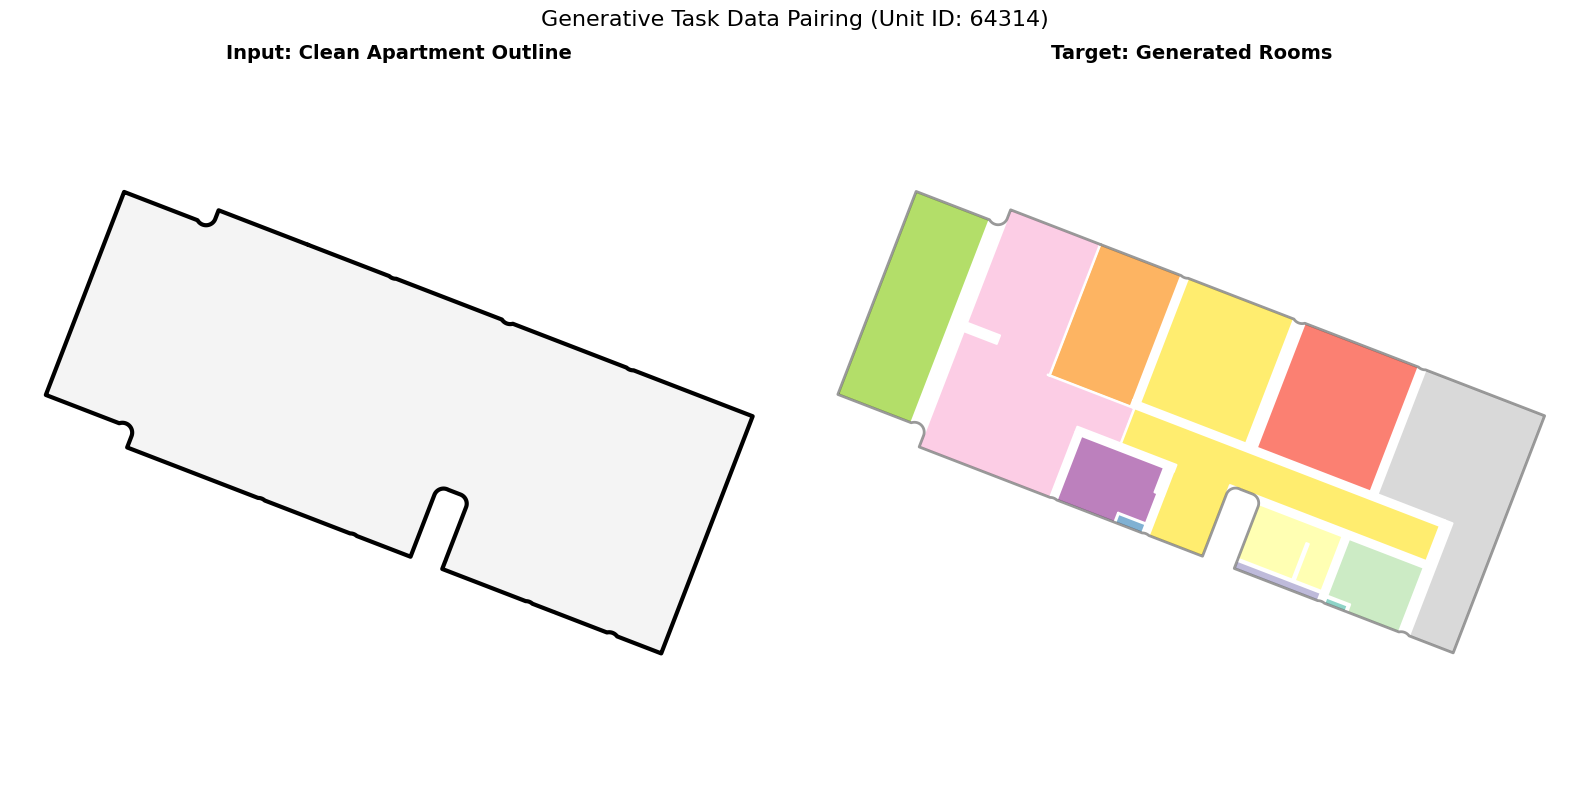

In [3]:
df = pd.read_csv(csv_path)
df['geom'] = df['geom'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry='geom')

# 2. Isolate a single apartment (a unit_id = one dwelling; a plan_id is a whole floor)
sample_unit_id = 64314
apartment_gdf = gdf[gdf['unit_id'] == sample_unit_id]
rooms_gdf = apartment_gdf[apartment_gdf['entity_type'] == 'area']

# Merge the rooms to create the outline
# 1. Buffer outward by 30 centimeters (MSD uses meters as units)
# 2. Cleanly unify them into one solid geometry
# 3. Buffer back inward by 30 centimeters to restore the original scale
wall_bridge_distance = 0.3
solid_outline_geom = rooms_gdf.geometry.buffer(wall_bridge_distance).union_all().buffer(-wall_bridge_distance)

# Convert the resulting Shapely geometry back into a GeoDataFrame for plotting
outline_gdf = gpd.GeoDataFrame(geometry=[solid_outline_geom], crs=rooms_gdf.crs)
# -------------------------------------

# 3. Plot side-by-side again
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left Plot: Condition
outline_gdf.plot(ax=ax1, facecolor='#f4f4f4', edgecolor='black', linewidth=3)
ax1.set_title("Input: Clean Apartment Outline", fontsize=14, fontweight='bold')
ax1.axis('equal')
ax1.axis('off')

# Right Plot: Target
rooms_gdf.plot(ax=ax2, cmap='Set3', edgecolor='white', linewidth=1.5)
outline_gdf.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=2, alpha=0.4)
ax2.set_title("Target: Generated Rooms", fontsize=14, fontweight='bold')
ax2.axis('equal')
ax2.axis('off')

plt.suptitle(f"Generative Task Data Pairing (Unit ID: {sample_unit_id})", fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
rooms_gdf = apartment_gdf[apartment_gdf['entity_type'] == 'area']
rooms_gdf

,Unnamed: 0.1,Unnamed: 0,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geom,elevation,height,zoning,roomtype
3202,3202,3202,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685866.0,RESIDENTIAL,area,SHAFT,"POLYGON ((5.70475 2.27894, 6.34733 2.03113, 6....",2.9,2.6,Structure,Structure
3203,3203,3203,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685860.0,RESIDENTIAL,area,BATHROOM,"POLYGON ((5.54883 2.48051, 4.73034 2.79616, 5....",2.9,2.6,Zone3,Bathroom
3204,3204,3204,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685865.0,RESIDENTIAL,area,SHAFT,"POLYGON ((5.43443 2.18387, 2.88402 3.16743, 2....",2.9,2.6,Structure,Structure
3205,3205,3205,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685856.0,RESIDENTIAL,area,ROOM,"POLYGON ((3.57331 6.85728, 5.0395 10.65918, 8....",2.9,2.6,Zone1,Bedroom
3206,3206,3206,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685864.0,RESIDENTIAL,area,SHAFT,"POLYGON ((0.06953 4.25284, -0.75026 4.56899, -...",2.9,2.6,Structure,Structure
3207,3207,3207,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685913.0,RESIDENTIAL,area,KITCHEN,"POLYGON ((-0.20623 8.31485, -0.28236 8.11744, ...",2.9,2.6,Zone2,Kitchen
3208,3208,3208,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685858.0,RESIDENTIAL,area,BALCONY,"POLYGON ((-4.59175 13.82125, -6.98372 7.61878,...",2.9,2.6,Zone4,Balcony
3209,3209,3209,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685912.0,RESIDENTIAL,area,LIVING_DINING,"POLYGON ((-4.27215 10.28773, -5.27897 10.67601...",2.9,2.6,Zone2,Livingroom
3210,3210,3210,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685857.0,RESIDENTIAL,area,ROOM,"POLYGON ((12.36833 7.83283, 9.57414 0.5874, 8....",2.9,2.6,Zone1,Bedroom
3211,3211,3211,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685863.0,RESIDENTIAL,area,STOREROOM,"POLYGON ((-0.65842 4.86935, -0.65892 4.86804, ...",2.9,2.6,Zone3,Storeroom


In [8]:
df.tail()

,Unnamed: 0.1,Unnamed: 0,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geom,elevation,height,zoning,roomtype
1086841,1175252,1175252,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,DOOR,POLYGON ((-1.429832052345855 3.331903160012016...,14.5,2.0,Door,Door
1086842,1175253,1175253,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,ENTRANCE_DOOR,POLYGON ((-3.50232000422389 3.3319031600120166...,14.5,2.0,Entrance Door,Entrance Door
1086843,1175254,1175254,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,WINDOW,POLYGON ((0.5283550488528448 5.786336039980052...,15.0,1.9,Window,Window
1086844,1175255,1175255,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,WINDOW,POLYGON ((-3.6279253346407394 5.80601415589792...,15.0,1.9,Window,Window
1086845,1175256,1175256,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,ENTRANCE_DOOR,POLYGON ((-3.767347251403443 5.706785944868615...,14.5,2.0,Entrance Door,Entrance Door


In [6]:
df.head()

,Unnamed: 0.1,Unnamed: 0,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geom,elevation,height,zoning,roomtype
0,0,0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,RESIDENTIAL,area,BATHROOM,POLYGON ((-2.733784407826521 4.079807440832154...,0.0,2.6,Zone3,Bathroom
1,1,1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,RESIDENTIAL,area,LIVING_ROOM,"POLYGON ((5.827898870188732 7.816876723402972,...",0.0,2.6,Zone2,Livingroom
2,2,2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619322.0,RESIDENTIAL,area,ROOM,"POLYGON ((6.755710720519119 2.413369594812586,...",0.0,2.6,Zone1,Bedroom
3,3,3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619310.0,RESIDENTIAL,area,KITCHEN,POLYGON ((3.5821200013910017 5.140461688341118...,0.0,2.6,Zone2,Kitchen
4,4,4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619312.0,RESIDENTIAL,area,ROOM,"POLYGON ((3.014138045548928 4.182056855151666,...",0.0,2.6,Zone1,Bedroom


In [7]:
df['geom']

0          POLYGON ((-2.733784407826521 4.079807440832154...
1          POLYGON ((5.827898870188732 7.816876723402972,...
2          POLYGON ((6.755710720519119 2.413369594812586,...
3          POLYGON ((3.5821200013910017 5.140461688341118...
4          POLYGON ((3.014138045548928 4.182056855151666,...
                                 ...                        
1086841    POLYGON ((-1.429832052345855 3.331903160012016...
1086842    POLYGON ((-3.50232000422389 3.3319031600120166...
1086843    POLYGON ((0.5283550488528448 5.786336039980052...
1086844    POLYGON ((-3.6279253346407394 5.80601415589792...
1086845    POLYGON ((-3.767347251403443 5.706785944868615...
Name: geom, Length: 1086846, dtype: object

In [9]:
apartment_gdf

,Unnamed: 0.1,Unnamed: 0,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geom,elevation,height,zoning,roomtype
3202,3202,3202,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685866.0,RESIDENTIAL,area,SHAFT,"POLYGON ((5.70475 2.27894, 6.34733 2.03113, 6....",2.9,2.6,Structure,Structure
3203,3203,3203,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685860.0,RESIDENTIAL,area,BATHROOM,"POLYGON ((5.54883 2.48051, 4.73034 2.79616, 5....",2.9,2.6,Zone3,Bathroom
3204,3204,3204,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685865.0,RESIDENTIAL,area,SHAFT,"POLYGON ((5.43443 2.18387, 2.88402 3.16743, 2....",2.9,2.6,Structure,Structure
3205,3205,3205,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685856.0,RESIDENTIAL,area,ROOM,"POLYGON ((3.57331 6.85728, 5.0395 10.65918, 8....",2.9,2.6,Zone1,Bedroom
3206,3206,3206,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685864.0,RESIDENTIAL,area,SHAFT,"POLYGON ((0.06953 4.25284, -0.75026 4.56899, -...",2.9,2.6,Structure,Structure
3207,3207,3207,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685913.0,RESIDENTIAL,area,KITCHEN,"POLYGON ((-0.20623 8.31485, -0.28236 8.11744, ...",2.9,2.6,Zone2,Kitchen
3208,3208,3208,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685858.0,RESIDENTIAL,area,BALCONY,"POLYGON ((-4.59175 13.82125, -6.98372 7.61878,...",2.9,2.6,Zone4,Balcony
3209,3209,3209,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685912.0,RESIDENTIAL,area,LIVING_DINING,"POLYGON ((-4.27215 10.28773, -5.27897 10.67601...",2.9,2.6,Zone2,Livingroom
3210,3210,3210,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685857.0,RESIDENTIAL,area,ROOM,"POLYGON ((12.36833 7.83283, 9.57414 0.5874, 8....",2.9,2.6,Zone1,Bedroom
3211,3211,3211,edfc14455d90520a69242447c695181f,1608,2800,7988,12962,64314.0,685863.0,RESIDENTIAL,area,STOREROOM,"POLYGON ((-0.65842 4.86935, -0.65892 4.86804, ...",2.9,2.6,Zone3,Storeroom


In [4]:
import pandas as pd

# 1. Quick structural summary
print("=== GEODATAFRAME STRUCTURE COMPARISON ===")
print(f"Rooms GDF   | Rows: {len(rooms_gdf)} | Columns: {list(rooms_gdf.columns)}")
print(f"Outline GDF | Rows: {len(outline_gdf)} | Columns: {list(outline_gdf.columns)}")
print("-" * 50)

# 2. Look at the data inside rooms_gdf
print("\n=== ROOMS ATTRIBUTE SAMPLE ===")
# Displaying key columns to see how the apartment is broken down
columns_to_show = [col for col in ['unit_id', 'entity_type', 'geometry'] if col in rooms_gdf.columns]
print(rooms_gdf[columns_to_show].head())

=== GEODATAFRAME STRUCTURE COMPARISON ===
Rooms GDF   | Rows: 13 | Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'apartment_id', 'site_id', 'building_id', 'plan_id', 'floor_id', 'unit_id', 'area_id', 'unit_usage', 'entity_type', 'entity_subtype', 'geom', 'elevation', 'height', 'zoning', 'roomtype']
Outline GDF | Rows: 1 | Columns: ['geometry']
--------------------------------------------------

=== ROOMS ATTRIBUTE SAMPLE ===
      unit_id entity_type
3202  64314.0        area
3203  64314.0        area
3204  64314.0        area
3205  64314.0        area
3206  64314.0        area


In [8]:
print("=== INDIVIDUAL ROOM GEOMETRIES (WKT) ===")
for idx, row in rooms_gdf.iterrows():
    # Using a sliced WKT string so it doesn't flood your screen with decimals
    wkt_snippet = str(row.geom) + "..."
    print(f"Room Index {idx}: {wkt_snippet}")

print("\n" + "="*50 + "\n")

print("=== UNIFIED OUTLINE GEOMETRY (WKT) ===")
# Grab the single geometry from the outline row
outline_geom = outline_gdf.geometry.iloc[0]
print(f"Outline: {str(outline_geom)[:100]}...")

=== INDIVIDUAL ROOM GEOMETRIES (WKT) ===
Room Index 3202: POLYGON ((5.7047486185526175 2.278935294194998, 6.347326322321546 2.0311266058774535, 6.280414312164282 1.8576211241555143, 5.637836608395354 2.1054298124730586, 5.7047486185526175 2.278935294194998))...
Room Index 3203: POLYGON ((5.548831678854485 2.4805117800181513, 4.730338155647145 2.796162019970076, 5.16130138040856 3.9136666613778957, 5.08803271152907 3.9419225635408637, 4.657069486767655 2.824417922133044, 2.998413879089494 3.4640748353724042, 3.6410536171934 5.130465025583636, 6.191471416958391 4.146901970229383, 5.548831678854485 2.4805117800181513))...
Room Index 3204: POLYGON ((5.4344331600274245 2.183871908181768, 2.884015360262431 3.167434963536021, 2.9749083274601666 3.4031240128070515, 5.525326127225156 2.4195609574527985, 5.4344331600274245 2.183871908181768))...
Room Index 3205: POLYGON ((3.5733093240280525 6.857282833811606, 5.039501202082743 10.659176208420625, 8.514076380532998 9.319213877978338, 7.0478845024

In [6]:
# Create a quick comparison table for geometric properties
metrics = {
    "Total Rooms Area (Sum)": rooms_gdf.geometry.area.sum(),
    "Unified Outline Area": outline_gdf.geometry.area.sum(),
    "Rooms Bounding Box": str(rooms_gdf.total_bounds),
    "Outline Bounding Box": str(outline_gdf.total_bounds),
    "Is Outline Valid?": outline_gdf.geometry.is_valid.iloc[0]
}

for key, val in metrics.items():
    print(f"{key:<30}: {val}")

Total Rooms Area (Sum)        : 138.50684104221324
Unified Outline Area          : 152.61949959503474
Rooms Bounding Box            : [-9.22763425  0.58740117 12.36832854 14.68660556]
Outline Bounding Box          : [-9.2271884   0.58784702 12.3678827  14.68615971]
Is Outline Valid?             : True
